<a href="https://colab.research.google.com/github/Niranjana-07/solar-tracking-system/blob/main/Forgery_Detection_Module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving gl-0038.jpg to gl-0038 (1).jpg


In [ ]:
uploaded.keys()


dict_keys(['gl-0038 (1).jpg'])

In [ ]:
import os

os.listdir("/content")


['.config', 'gl-0038.jpg', 'gl-0038 (1).jpg', 'sample_data']

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/gl-0038.jpg"  # change path
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

assert img is not None, "Image not loaded"


In [ ]:
# Example patch coordinates (adjust if needed)
src_x, src_y = 60, 80
patch_w, patch_h = 40, 40

patch = img[src_y:src_y+patch_h, src_x:src_x+patch_w]


In [ ]:
tgt_x, tgt_y = 140, 150


In [ ]:
forged_img = img.copy()
forged_img[tgt_y:tgt_y+patch_h, tgt_x:tgt_x+patch_w] = patch


In [ ]:
gt_mask = np.zeros_like(img, dtype=np.uint8)
gt_mask[tgt_y:tgt_y+patch_h, tgt_x:tgt_x+patch_w] = 255


In [ ]:
forged_img[tgt_y:tgt_y+patch_h, tgt_x:tgt_x+patch_w] = cv2.GaussianBlur(
    forged_img[tgt_y:tgt_y+patch_h, tgt_x:tgt_x+patch_w],
    (3,3), 0
)


In [ ]:
cv2.imwrite("/content/forged_mri.png", forged_img)
cv2.imwrite("/content/gt_mask.png", gt_mask)


True

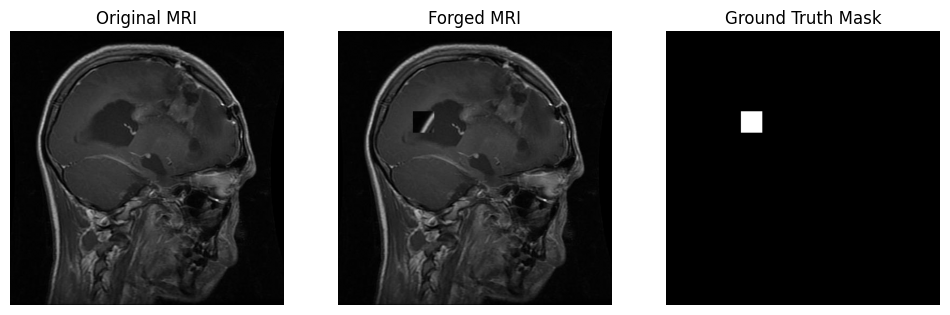

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original MRI")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Forged MRI")
plt.imshow(forged_img, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Ground Truth Mask")
plt.imshow(gt_mask, cmap='gray')
plt.axis('off')

plt.show()


In [ ]:
from google.colab import files

files.download("/content/forged_mri.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>